### Práctica individual
- Detectar figuras en una imagen, calcular sus momentos y clasificarlas (aproximadamente) como círculo, cuadrado o triángulo en función de la forma de su contorno.
- Calcular los momentos de Hu (cv2.HuMoments).
- Aproximación del contorno con cv2.approxPolyDP para contar vértices.
- Clasificar la figura por vertices

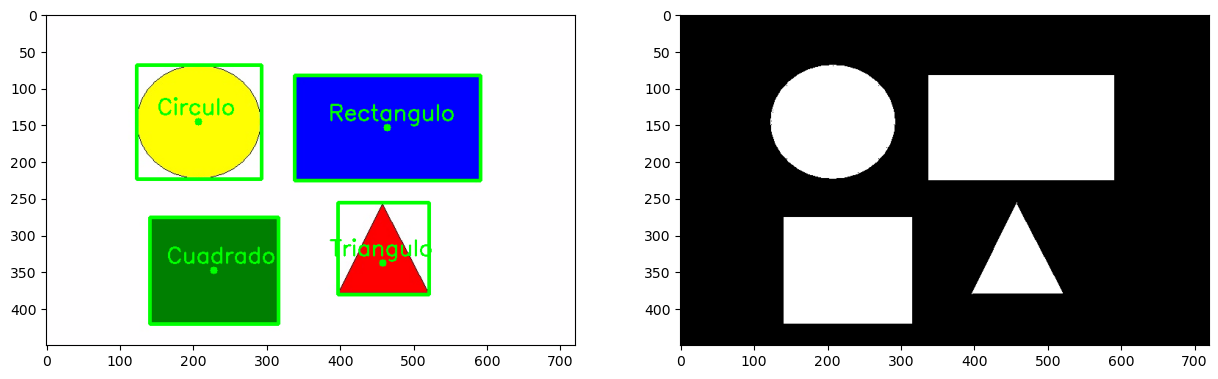

Contorno 1: Perimetro: 636.0, Area: 25056.0
Momentos de Hu: [0.16965996 0.00100672 0.         0.         0.         0.
 0.        ] 

Contorno 2: Perimetro: 422.19090580940247, Area: 7472.0
Momentos de Hu: [ 1.94087977e-01  6.34561499e-04  4.61925932e-03  2.15059257e-05
  6.64711529e-09  5.27737941e-07 -1.32731265e-09] 

Contorno 3: Perimetro: 788.0, Area: 35784.0
Momentos de Hu: [0.194845   0.01018679 0.         0.         0.         0.
 0.        ] 

Contorno 4: Perimetro: 535.8721461296082, Area: 20316.0
Momentos de Hu: [ 1.59848107e-01  2.19086627e-04  6.32296043e-31  1.18123806e-30
  1.01084138e-60  1.19694278e-32 -1.42673657e-61] 



In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def bin_img(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _, bin = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)
  return bin

# imagenes para comparar
circulo = cv2.imread('./images/circulo.png')
cuadrado = cv2.imread('./images/cuadrado.jpg')

circulo = bin_img(circulo)
cuadrado = bin_img(cuadrado)

contorno_circulo = cv2.findContours(circulo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
contorno_cuadrado = cv2.findContours(cuadrado, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

# Cargar la imagen
img = cv2.imread('./images/figuras.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(img_gray, 230, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []
momentos_hu = []

for i in range(len(contorno)):
  cnt = contorno[i]
  M = cv2.moments(cnt)
  hu_moments = cv2.HuMoments(M).flatten()
  momentos_hu.append(hu_moments)
  
  if (M['m00'] != 0):
    # Valores enteros para el centroide
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
  else:
    cx, cy = 0, 0

  circulo_diff = cv2.matchShapes(contorno_circulo[0], cnt, cv2.CONTOURS_MATCH_I2, 0)
  cuadrado_diff = cv2.matchShapes(contorno_cuadrado[0], cnt, cv2.CONTOURS_MATCH_I2, 0)

  best_match = min(circulo_diff, cuadrado_diff)
  nombre_figura = ""
  if best_match == circulo_diff:
    nombre_figura = "Circulo"
  elif best_match == cuadrado_diff:
    nombre_figura = "Cuadrado"
  
  if best_match > 0.01:
    nombre_figura = "Desconocido"

  approx = cv2.approxPolyDP(cnt, 0.02 * perimetro, True)
  vertices = len(approx)
  
  if (nombre_figura == "Desconocido"):
    if (vertices == 3):
      nombre_figura = "Triangulo"
    elif (vertices == 4):
      nombre_figura = "Rectangulo"
      

  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)

  perimetros.append(perimetro)
  areas.append(area)

  cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
  
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)
  cv2.putText(img, nombre_figura, (cx - len(nombre_figura) * 8, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
  # cv2.putText(img, f"{round(best_match, 3)}", (cx - 20, cy + 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)


plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(bin, cmap='gray')
plt.show()

for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
  print(f"Contorno {i+1}: Perimetro: {perimetro}, Area: {area}")
  print(f"Momentos de Hu: {momentos_hu[i]} \n")